In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

In [20]:
# Check Devices
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [21]:
# Generate data and convert to tensors
X = np.arange(0, 1, 0.02)
y = 5.66*X + 3.227

split = int(len(X)*0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]
X_train, y_train = torch.from_numpy(X_train), torch.from_numpy(y_train)
X_test, y_test = torch.from_numpy(X_test), torch.from_numpy(y_test)

In [22]:
def plot_data(X_train, y_train, X_test, y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X'); plt.ylabel('y')
    plt.title('X vs y'); plt.legend(); plt.show()

In [23]:
# Define the modal class
class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
          
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [24]:
# Instantiate the Model
torch.manual_seed(42)
model = MyFirstNeuralNetwork()
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

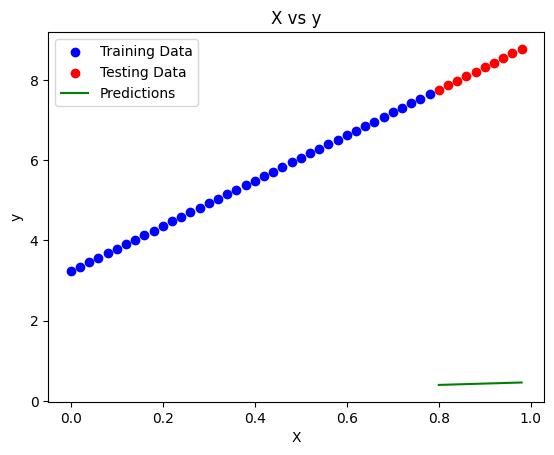

In [25]:
# Prediction before training
with torch.inference_mode():
    y_pred = model(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)

In [40]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    params=model.parameters(),lr=0.1
)


In [41]:
epochs = 200
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    model.train()
    train_pred = model(X_train)
    loss = loss_fn(y_train, train_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(y_test, test_pred)
    train_loss_list.append(loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())

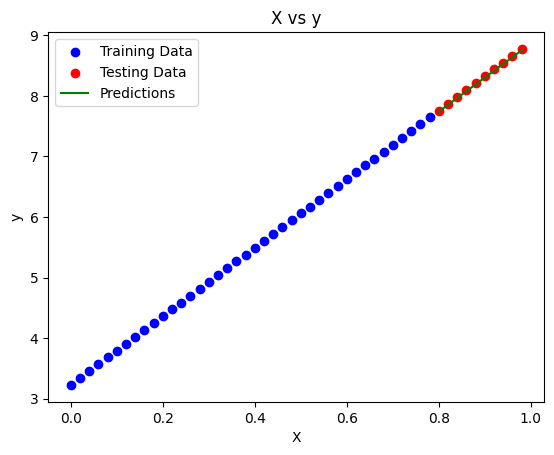

In [42]:
with torch.inference_mode():
    y_pred = model(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)

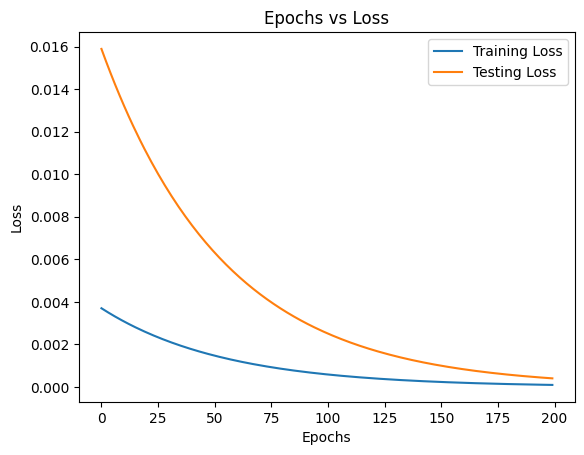

In [43]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [45]:
# Using Adam as optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),lr=0.1
)

In [46]:
epochs = 200
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    model.train()
    train_pred = model(X_train)
    loss = loss_fn(y_train, train_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(y_test, test_pred)
    train_loss_list.append(loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())

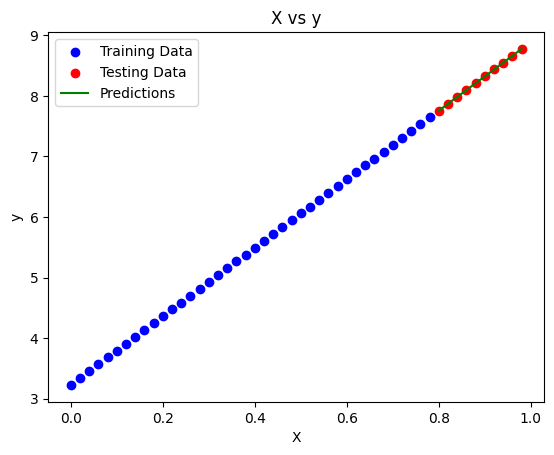

In [47]:
with torch.inference_mode():
    y_pred = model(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)

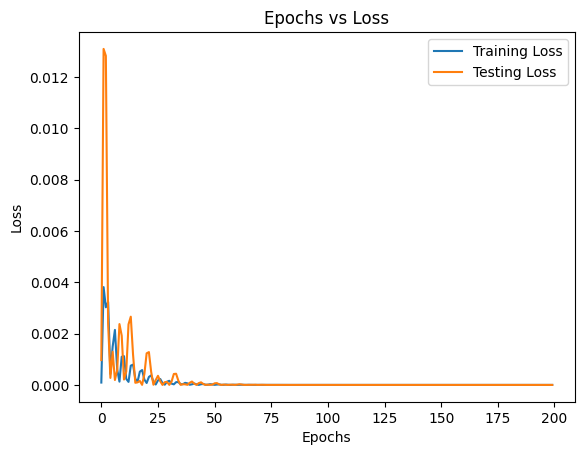

In [48]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Multiple Linear Regression

In [65]:
A = 5.42
B = 6.33
C = 0.98
X1 = np.arange(0, 1, 0.02)
X2 = np.arange(1, 2, 0.02)
X = np.column_stack((X1, X2))
y = A * X1 + B * X2 + C

# Train/Test split
split = int(len(X) * 0.8)

X_train = torch.tensor(X[:split], dtype=torch.float32)
X_test  = torch.tensor(X[split:], dtype=torch.float32)

y_train = torch.tensor(y[:split], dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y[split:], dtype=torch.float32).unsqueeze(1)

In [66]:
class MySecondNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(2, 1, requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
          
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x @ self.weights + self.bias

In [67]:
torch.manual_seed(42)

model_2 = MySecondNeuralNetwork()

print(model_2.state_dict())

OrderedDict({'weights': tensor([[0.3367],
        [0.1288]]), 'bias': tensor([0.2345])})


In [69]:
with torch.inference_mode():
    y_pred = model_2(X_test)

print("Predictions before training:")
print(y_pred[:5])

Predictions before training:
tensor([[0.7357],
        [0.7450],
        [0.7543],
        [0.7636],
        [0.7729]])


In [70]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.1
)

In [71]:
epochs = 200

train_loss_list = []
test_loss_list = []

for epoch in range(epochs):

    model_2.train()

    train_pred = model_2(X_train)

    loss = loss_fn(train_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_2.eval()

    with torch.inference_mode():

        test_pred = model_2(X_test)

        test_loss = loss_fn(test_pred, y_test)

    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch   0 | Train Loss: 135.5571 | Test Loss: 58.4693
Epoch  20 | Train Loss: 0.7435 | Test Loss: 2.9928
Epoch  40 | Train Loss: 0.4937 | Test Loss: 1.9872
Epoch  60 | Train Loss: 0.3278 | Test Loss: 1.3194
Epoch  80 | Train Loss: 0.2177 | Test Loss: 0.8761
Epoch 100 | Train Loss: 0.1445 | Test Loss: 0.5817
Epoch 120 | Train Loss: 0.0960 | Test Loss: 0.3862
Epoch 140 | Train Loss: 0.0637 | Test Loss: 0.2565
Epoch 160 | Train Loss: 0.0423 | Test Loss: 0.1703
Epoch 180 | Train Loss: 0.0281 | Test Loss: 0.1131


In [72]:
with torch.inference_mode():
    y_pred = model_2(X_test)

print("Predictions after training:")
print(y_pred[:10])

Predictions after training:
tensor([[16.4880],
        [16.7113],
        [16.9345],
        [17.1578],
        [17.3811],
        [17.6044],
        [17.8277],
        [18.0509],
        [18.2742],
        [18.4975]])


In [73]:
print("Actual\t\tPredicted")

for actual, pred in zip(y_test[:10], y_pred[:10]):
    print(f"{actual.item():.4f}\t\t{pred.item():.4f}")

Actual		Predicted
16.7100		16.4880
16.9450		16.7113
17.1800		16.9345
17.4150		17.1578
17.6500		17.3811
17.8850		17.6044
18.1200		17.8277
18.3550		18.0509
18.5900		18.2742
18.8250		18.4975


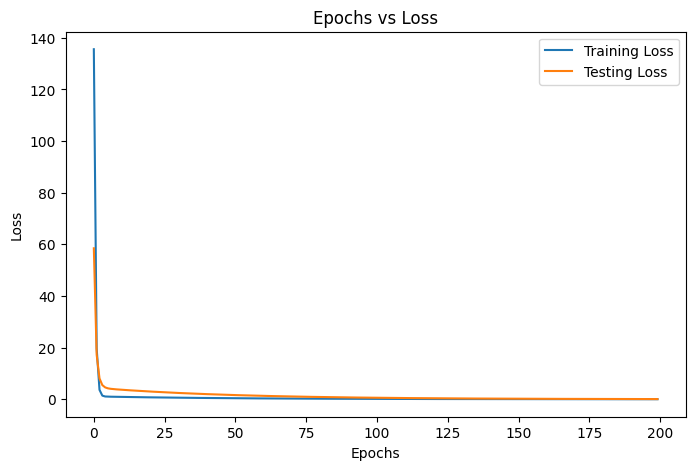

In [74]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list,label="Training Loss")
plt.plot(test_loss_list,label="Testing Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs Loss")

plt.legend()

plt.show()

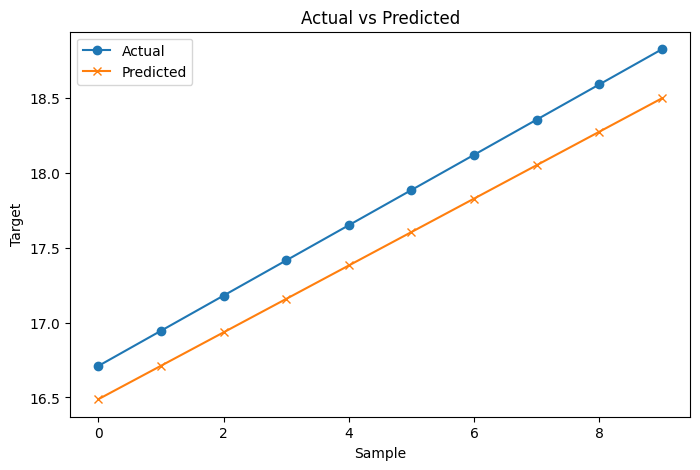

In [75]:
plt.figure(figsize=(8,5))

plt.plot(y_test.numpy(),label="Actual",marker='o')
plt.plot(y_pred.numpy(),label="Predicted",marker='x')

plt.xlabel("Sample")
plt.ylabel("Target")

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

In [76]:
print("Learned Parameters")

print("Weights:")
print(model_2.weights)

print("Bias:")
print(model_2.bias)

Learned Parameters
Weights:
Parameter containing:
tensor([[5.0710],
        [6.0928]], requires_grad=True)
Bias:
Parameter containing:
tensor([1.4642], requires_grad=True)


In [77]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test.numpy(),
    y_pred.numpy()
)

print("R² Score:", r2)

R² Score: 0.8318080306053162


In [78]:
# Save the trained model
MODEL_PATH = "simple_linear_regression.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved successfully!")

# Load the saved model
loaded_model_1 = MyFirstNeuralNetwork()
loaded_model_1.load_state_dict(torch.load(MODEL_PATH))
loaded_model_1.eval()

# Compare Predictions
with torch.inference_mode():
    original_pred = model(X_test)
    loaded_pred = loaded_model_1(X_test)

print("\nOriginal Predictions:")
print(original_pred)

print("\nLoaded Model Predictions:")
print(loaded_pred)

# Verify Predictions
print("\nDo both models give the same predictions?")
print(torch.allclose(original_pred, loaded_pred))

Model saved successfully!

Original Predictions:
tensor([[ 7.7550, 13.4150],
        [ 7.8682, 13.5282],
        [ 7.9814, 13.6414],
        [ 8.0946, 13.7546],
        [ 8.2078, 13.8678],
        [ 8.3210, 13.9810],
        [ 8.4342, 14.0942],
        [ 8.5474, 14.2074],
        [ 8.6606, 14.3206],
        [ 8.7738, 14.4338]])

Loaded Model Predictions:
tensor([[ 7.7550, 13.4150],
        [ 7.8682, 13.5282],
        [ 7.9814, 13.6414],
        [ 8.0946, 13.7546],
        [ 8.2078, 13.8678],
        [ 8.3210, 13.9810],
        [ 8.4342, 14.0942],
        [ 8.5474, 14.2074],
        [ 8.6606, 14.3206],
        [ 8.7738, 14.4338]])

Do both models give the same predictions?
True


In [79]:
# For Multiple linear regression
MODEL_PATH = "multiple_linear_regression.pth"
torch.save(model_2.state_dict(), MODEL_PATH)
print("Model saved successfully!")

# Load 
loaded_model_2 = MySecondNeuralNetwork()
loaded_model_2.load_state_dict(torch.load(MODEL_PATH))
loaded_model_2.eval()

# Compare
with torch.inference_mode():
    original_pred = model_2(X_test)
    loaded_pred = loaded_model_2(X_test)

print("\nOriginal Predictions:")
print(original_pred)

print("\nLoaded Model Predictions:")
print(loaded_pred)

# Verify
print("\nDo both models give the same predictions?")
print(torch.allclose(original_pred, loaded_pred))

Model saved successfully!

Original Predictions:
tensor([[16.4880],
        [16.7113],
        [16.9345],
        [17.1578],
        [17.3811],
        [17.6044],
        [17.8277],
        [18.0509],
        [18.2742],
        [18.4975]])

Loaded Model Predictions:
tensor([[16.4880],
        [16.7113],
        [16.9345],
        [17.1578],
        [17.3811],
        [17.6044],
        [17.8277],
        [18.0509],
        [18.2742],
        [18.4975]])

Do both models give the same predictions?
True
